# Lecture 8 — Class Exercise
## Choropleth Maps

> **Push to:** `week08/lecture08_exercise.ipynb`

**Rules:**
1. Use `px.choropleth` or `px.choropleth_map` — choose deliberately and state your reason
2. Right colour scale for your data (sequential vs diverging) — state which and why
3. Insight title names a geographic finding — not just a topic
4. `featureidkey` must be correctly matched to your GeoJSON

---


In [29]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import json


In [30]:
FONT_FAMILY  = 'Arial'
FONT_COLOR   = '#1a1a2e'

TITLE_SIZE   = 17
AXIS_SIZE    = 11

BG_COLOR     = '#ffffff'

COLORBAR_LEN = 0.58
HEIGHT       = 580

## Task 1 — World choropleth: life expectancy diverging scale

**What to build:** A world choropleth showing **life expectancy relative to the global average** using a diverging colour scale.

**Requirements:**
- Use the Gapminder dataset for 2007: `px.data.gapminder()`
- Compute each country's deviation from the global mean life expectancy
- Diverging scale centred at zero (= world average)
- `hover_data` showing country name, raw life expectancy, and deviation
- Insight title naming which region is furthest below average

> 💡 `gm_2007['lifeExp'].mean()` gives you the global average to subtract from


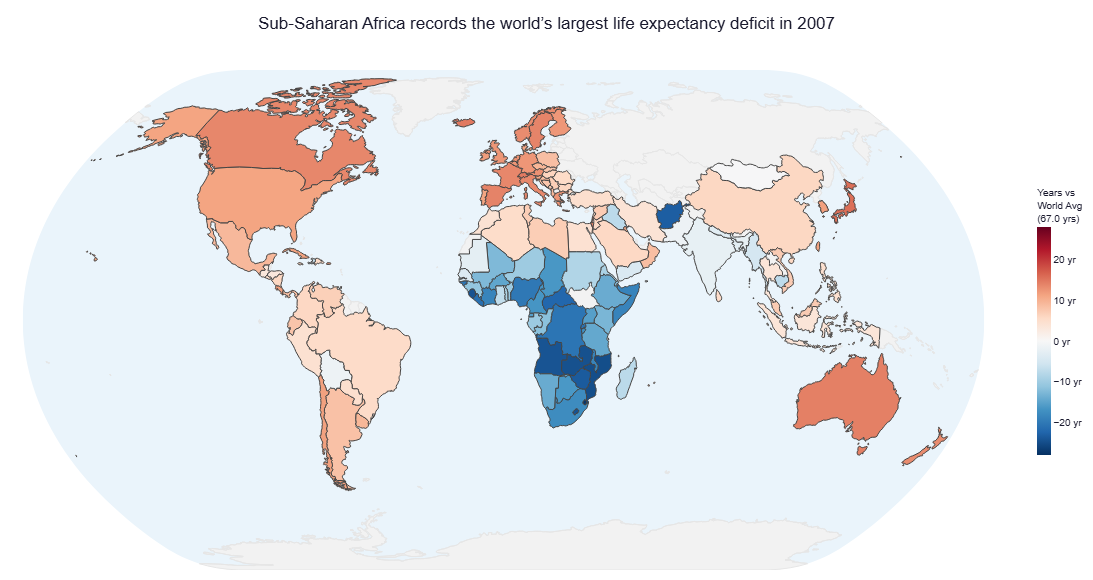

In [31]:
# Task 1

gm = px.data.gapminder()

gm_2007 = gm[gm['year'] == 2007].copy()

# Global average life expectancy
global_mean_life = gm_2007['lifeExp'].mean()

# Deviation from global average
# Positive = above average
# Negative = below average

gm_2007['lifeExp_dev'] = (
    gm_2007['lifeExp'] - global_mean_life
)

# Create formatted hover labels
gm_2007['lifeExp_dev_label'] = (
    gm_2007['lifeExp_dev']
    .map(lambda x: f'{x:+.1f} yrs')
)

# ============================================================
# Step 2 — Create symmetric color scale range
# ============================================================

max_abs = max(
    abs(gm_2007['lifeExp_dev'].min()),
    abs(gm_2007['lifeExp_dev'].max())
)

max_abs_rounded = np.ceil(max_abs)

# ============================================================
# Step 3 — Build choropleth
# ============================================================

fig1 = px.choropleth(
    gm_2007,

    locations='iso_alpha',
    locationmode='ISO-3',

    color='lifeExp_dev',

    # Diverging scale:
    # red = below average
    # blue = above average
    color_continuous_scale='RdBu_r',

    color_continuous_midpoint=0,

    # Symmetric range keeps midpoint visually balanced
    range_color=[
        -max_abs_rounded,
         max_abs_rounded
    ],

    hover_name='country',

    hover_data={
        'iso_alpha'        : False,
        'lifeExp'          : ':.1f',
        'lifeExp_dev_label': True,
        'continent'        : True,
        'lifeExp_dev'      : False,
    },

    labels={
        'lifeExp'          : 'Life Expectancy',
        'lifeExp_dev_label': 'vs World Avg',
        'continent'        : 'Continent',
    },

    projection='natural earth',

    title=(
        'Sub-Saharan Africa records the world’s largest '
        'life expectancy deficit in 2007'
    ),

    height=HEIGHT,
)

# ============================================================
# Step 4 — Layout styling
# ============================================================

fig1.update_layout(

    template='plotly_white',

    font=dict(
        family=FONT_FAMILY,
        color=FONT_COLOR,
        size=AXIS_SIZE
    ),

    title=dict(
        font=dict(
            size=TITLE_SIZE,
            family=FONT_FAMILY,
            color=FONT_COLOR
        ),
        x=0.5,
        xanchor='center',
        y=0.97
    ),

    paper_bgcolor=BG_COLOR,

    margin=dict(
        l=0,
        r=0,
        t=70,
        b=10
    ),

    coloraxis_colorbar=dict(

        title=dict(
            text=(
                f'Years vs<br>'
                f'World Avg<br>'
                f'({global_mean_life:.1f} yrs)'
            ),
            font=dict(
                size=10,
                family=FONT_FAMILY,
                color=FONT_COLOR
            )
        ),

        ticksuffix=' yr',

        thickness=14,

        len=COLORBAR_LEN,

        tickfont=dict(
            size=10,
            color=FONT_COLOR
        ),

        outlinewidth=0
    ),
)

# ============================================================
# Step 5 — Geographic styling
# ============================================================

fig1.update_geos(

    showframe=False,

    showcoastlines=True,
    coastlinecolor='#e6e6e6',

    showcountries=True,
    countrycolor='#e6e6e6',

    showland=True,
    landcolor='#f2f2f2',

    showocean=True,
    oceancolor='#eaf4fb',

    showlakes=False,

    projection_type='natural earth',

    bgcolor='rgba(0,0,0,0)'
)

# ============================================================
# Step 6 — Source annotation
# ============================================================

fig1.add_annotation(

    text='Source: Gapminder dataset (2007) via Plotly Express',

    xref='paper',
    yref='paper',

    x=0.0,
    y=-0.06,

    showarrow=False,

    font=dict(
        size=9,
        color='#888888',
        family=FONT_FAMILY
    ),

    align='left'
)

fig1.show()

## Task 2 — Find your own GeoJSON

**What to build:** A choropleth using a GeoJSON file you find yourself online.

**Requirements:**
- Find a free GeoJSON file for any geography that interests you (country, region, city)
- Create or find a matching dataset with at least one numeric variable per region
- Build either a `px.choropleth` or `px.choropleth_mapbox` — state your choice and reason in the markdown cell below
- Correctly identify and set `featureidkey` by inspecting the GeoJSON properties
- Choose sequential or diverging scale — state your reason in the markdown cell below
- Insight title naming a geographic finding

**Where to find GeoJSON files:**
- [geojson.xyz](https://geojson.xyz/) — countries, cities, natural features
- [naturalearthdata.com](https://www.naturalearthdata.com/) — global admin boundaries
- [github.com/datasets/geo-countries](https://github.com/datasets/geo-countries) — country polygons
- Search: `[country name] [admin level] GeoJSON github` — most countries have free boundary files on GitHub

> 💡 Before plotting, always inspect your GeoJSON properties first:
> ```python
> print(my_geojson['features'][0]['properties'])
> ```
> The property name that matches your dataframe's location column is what goes in `featureidkey='properties.???'`


### Task 2 — Design decisions

**GeoJSON source:** *(URL or description)*

**Chart type chosen** (`px.choropleth` or `px.choropleth_mapbox`) **and reason:**

*Your answer here*

**Colour scale chosen** (sequential or diverging) **and reason:**

*Your answer here*

# Task 2 — Design Decisions

## GeoJSON source

European country boundaries GeoJSON from:

https://github.com/leakyMirror/map-of-europe

The GeoJSON file contains European country polygons with ISO3 country codes used to match the Gapminder dataset.

---

## Chart type chosen and reason

### `px.choropleth`

A standard choropleth map was chosen because the analysis compares country-level GDP per capita across Europe rather than requiring street-level geographic detail.

`px.choropleth` is appropriate because:

* it directly supports GeoJSON polygon mapping
* it is ideal for thematic statistical visualisations
* it does not require a Mapbox access token
* it provides cleaner presentation for continental-scale analysis

---

## Colour scale chosen and reason

### Sequential colour scale (`Blues`)

A sequential colour scale was selected because GDP per capita is a continuous positive numeric variable with a natural progression from low to high values.

Darker shades represent wealthier countries, making regional economic disparities easier to interpret.

A diverging scale was not used because there is no meaningful central midpoint in GDP per capita values.


In [32]:
# Task 2
# YOUR CODE HERE

# Load your GeoJSON
# with open('your_file.geojson', 'r') as file:
#     my_geojson = json.load(file)

# Inspect the properties to find the right featureidkey
# print(my_geojson['features'][0]['properties'])


# ─────────────────────────────────────────────────────────────────────────
#  TASK 2 — European GDP per Capita (Gapminder 2007 + Custom GeoJSON)
# ─────────────────────────────────────────────────────────────────────────
import requests

# ── Step 1: Fetch the GeoJSON ─────────────────────────────────────────────
EUROPE_GEOJSON_URL = (
    'https://raw.githubusercontent.com/leakyMirror/map-of-europe/'
    'master/GeoJSON/europe.geojson'
)
response       = requests.get(EUROPE_GEOJSON_URL, timeout=20)
europe_geojson = response.json()

# ── Step 2: Inspect the GeoJSON properties ────────────────────────────────
# ALWAYS inspect before setting featureidkey — avoids silent mismatches
print("GeoJSON feature count:", len(europe_geojson['features']))
print("\nSample properties (first feature):")
print(europe_geojson['features'][0]['properties'])
print("\n→ We will use featureidkey='properties.ISO3' to match iso_alpha in our dataframe.")




GeoJSON feature count: 51

Sample properties (first feature):
{'FID': 0.0, 'FIPS': 'AJ', 'ISO2': 'AZ', 'ISO3': 'AZE', 'UN': 31, 'NAME': 'Azerbaijan', 'AREA': 8260, 'POP2005': 8352021, 'REGION': 142, 'SUBREGION': 145, 'LON': 47.395, 'LAT': 40.43}

→ We will use featureidkey='properties.ISO3' to match iso_alpha in our dataframe.


In [33]:
# ── Step 3: Prepare the dataset ───────────────────────────────────────────
europe_data = gm_2007[gm_2007['continent'] == 'Europe'].copy()

# Format GDP for readable hover labels (thousands)
europe_data['gdpPercap_k']    = (europe_data['gdpPercap'] / 1000).round(1)
europe_data['gdpPercap_fmt']  = europe_data['gdpPercap'].apply(lambda x: f"${x:,.0f}")

# Verify match between GeoJSON ISO3 and dataframe iso_alpha
geojson_iso3 = {f['properties']['ISO3'] for f in europe_geojson['features']}
df_iso3      = set(europe_data['iso_alpha'])
matched      = df_iso3 & geojson_iso3
unmatched    = df_iso3 - geojson_iso3

print(f"Countries in Gapminder Europe: {len(df_iso3)}")
print(f"Matched to GeoJSON: {len(matched)}")
if unmatched:
    print(f"Unmatched (will appear grey): {unmatched}")

print("\nGDP per Capita range (Europe):")
print(europe_data[['country','gdpPercap']]
      .sort_values('gdpPercap', ascending=False)
      .to_string(index=False))

Countries in Gapminder Europe: 30
Matched to GeoJSON: 30

GDP per Capita range (Europe):
               country    gdpPercap
                Norway 49357.190170
               Ireland 40675.996350
           Switzerland 37506.419070
           Netherlands 36797.933320
               Iceland 36180.789190
               Austria 36126.492700
               Denmark 35278.418740
                Sweden 33859.748350
               Belgium 33692.605080
               Finland 33207.084400
        United Kingdom 33203.261280
               Germany 32170.374420
                France 30470.016700
                 Spain 28821.063700
                 Italy 28569.719700
                Greece 27538.411880
              Slovenia 25768.257590
        Czech Republic 22833.308510
              Portugal 20509.647770
       Slovak Republic 18678.314350
               Hungary 18008.944440
                Poland 15389.924680
               Croatia 14619.222720
               Romania 10808.475610
           

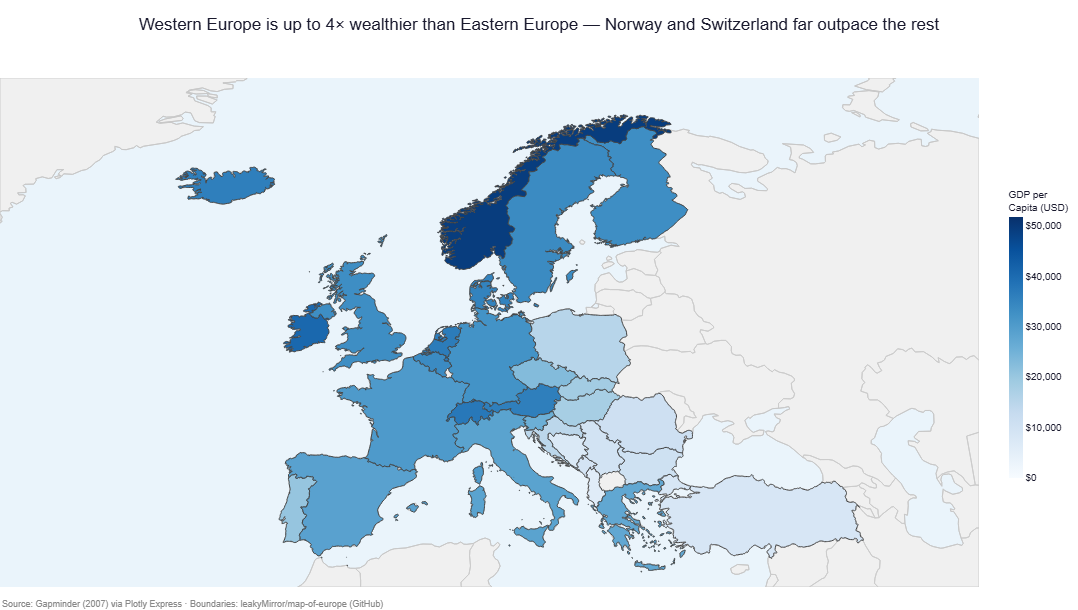

In [35]:
# ── Step 4: Build the choropleth ─────────────────────────────────────────

fig2 = px.choropleth(
    europe_data,
    geojson       = europe_geojson,
    locations     = 'iso_alpha',
    featureidkey  = 'properties.ISO3',       # matched after inspecting GeoJSON
    color         = 'gdpPercap',
    color_continuous_scale = 'Blues',         # sequential — GDP is one-directional
    range_color   = [0, europe_data['gdpPercap'].max() * 1.05],  # zero-based axis
    hover_name    = 'country',
    hover_data    = {
        'iso_alpha'    : False,
        'gdpPercap'    : ':,.0f',
        'lifeExp'      : ':.1f',
        'pop'          : ':,.0f',
    },
    labels        = {
        'gdpPercap': 'GDP per Capita (USD)',
        'lifeExp'  : 'Life Expectancy (yrs)',
        'pop'      : 'Population',
    },
    fitbounds     = 'locations',              # auto-zoom to European data extent
    projection    = 'natural earth',
    title         = (
        'Western Europe is up to 4× wealthier than Eastern Europe — '
        'Norway and Switzerland far outpace the rest'
    ),
    height        = HEIGHT + 30,
)

# ── Step 5: Polish layout ─────────────────────────────────────────────────
fig2.update_layout(
    font   = dict(family=FONT_FAMILY, color=FONT_COLOR, size=AXIS_SIZE),
    title  = dict(
        font    = dict(size=TITLE_SIZE, family=FONT_FAMILY, color=FONT_COLOR),
        x       = 0.5,
        xanchor = 'center',
        y       = 0.97,
    ),
    paper_bgcolor = BG_COLOR,
    margin        = dict(l=0, r=0, t=65, b=10),
    coloraxis_colorbar = dict(
        title       = dict(
            text = 'GDP per<br>Capita (USD)',
            font = dict(size=10, family=FONT_FAMILY, color=FONT_COLOR),
        ),
        tickprefix  = '$',
        tickformat  = ',.0f',
        thickness   = 14,
        len         = COLORBAR_LEN,
        tickfont    = dict(size=10, color=FONT_COLOR),
        outlinewidth= 0,
    ),
    geo = dict(
        showframe      = False,
        showcoastlines = True,
        coastlinecolor = '#c8c8c8',
        showland       = True,
        landcolor      = '#f0f0f0',    # grey for countries not in dataset
        showocean      = True,
        oceancolor     = '#eaf4fb',
        showlakes      = False,
        showcountries  = True,
        countrycolor   = '#cccccc',
    ),
)

# ── Step 6: Source annotation ─────────────────────────────────────────────
fig2.add_annotation(
    text      = (
        'Source: Gapminder (2007) via Plotly Express · '
        'Boundaries: leakyMirror/map-of-europe (GitHub)'
    ),
    xref='paper', yref='paper',
    x=0.0, y=-0.02,
    showarrow = False,
    font      = dict(size=9, color='#888888', family=FONT_FAMILY),
    align     = 'left',
)

fig2.show()

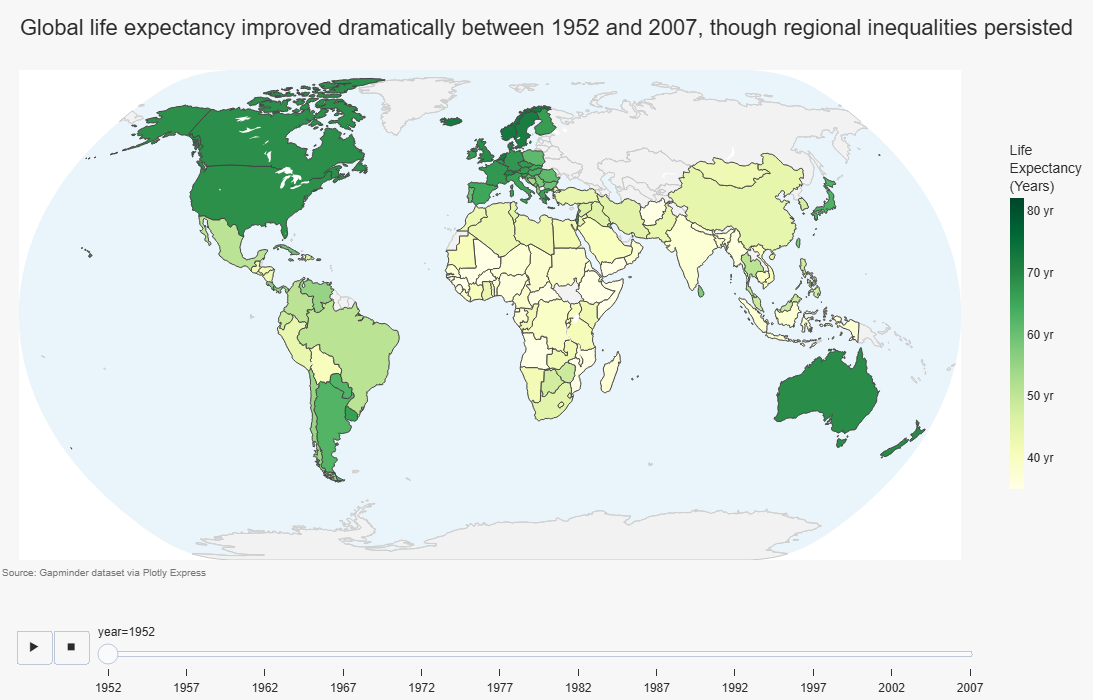

In [36]:
# ─────────────────────────────────────────────────────────────
# STRETCH TASK — Animated Global Life Expectancy Map
# Gapminder Dataset (1952–2007)
# ─────────────────────────────────────────────────────────────

import plotly.express as px

# ============================================================
# DESIGN DECISIONS
# ============================================================

"""
Chart Type:
Animated px.choropleth

Reason:
Animation effectively communicates long-term global changes
in life expectancy over time while preserving geographic context.

Colour Scale:
Sequential ("YlGn")

Reason:
Life expectancy is a continuous positive metric where higher
values indicate better outcomes. A sequential scale best
represents progression from low to high.
"""

# ============================================================
# CONFIGURATION
# ============================================================

FONT_FAMILY = "Arial"
FONT_COLOR  = "#2b2b2b"

TITLE_SIZE  = 22
TEXT_SIZE   = 12

BACKGROUND  = "#f7f7f7"

OCEAN_COLOR = "#eaf4fb"
LAND_COLOR  = "#f2f2f2"

CHART_HEIGHT = 700

# ============================================================
# BUILD ANIMATED CHOROPLETH
# ============================================================

fig = px.choropleth(

    gm,

    locations="iso_alpha",

    locationmode="ISO-3",

    color="lifeExp",

    animation_frame="year",

    projection="natural earth",

    color_continuous_scale="YlGn",

    range_color=[35, 82],

    hover_name="country",

    hover_data={
        "iso_alpha": False,
        "lifeExp": ":.1f",
        "gdpPercap": ":,.0f",
        "pop": ":,.0f"
    },

    labels={
        "lifeExp": "Life Expectancy (Years)",
        "gdpPercap": "GDP per Capita (USD)",
        "pop": "Population"
    },

    title=(
        "Global life expectancy improved dramatically "
        "between 1952 and 2007, though regional inequalities persisted"
    ),

    height=CHART_HEIGHT
)

# ============================================================
# GLOBAL LAYOUT
# ============================================================

fig.update_layout(

    paper_bgcolor=BACKGROUND,

    margin=dict(
        l=0,
        r=0,
        t=70,
        b=10
    ),

    font=dict(
        family=FONT_FAMILY,
        size=TEXT_SIZE,
        color=FONT_COLOR
    ),

    title=dict(
        x=0.5,
        xanchor="center",
        font=dict(
            size=TITLE_SIZE
        )
    ),

    coloraxis_colorbar=dict(

        title=dict(
            text="Life<br>Expectancy<br>(Years)"
        ),

        ticksuffix=" yr",

        thickness=14,

        len=0.75,

        outlinewidth=0
    ),

    geo=dict(

        showframe=False,

        showcountries=True,
        countrycolor="#c8c8c8",

        showcoastlines=True,
        coastlinecolor="#d0d0d0",

        showland=True,
        landcolor=LAND_COLOR,

        showocean=True,
        oceancolor=OCEAN_COLOR
    )
)

# ============================================================
# IMPROVE ANIMATION SMOOTHNESS
# ============================================================

fig.layout.updatemenus[0].buttons[0].args[1]["frame"]["duration"] = 700

fig.layout.updatemenus[0].buttons[0].args[1]["transition"]["duration"] = 400

# ============================================================
# SOURCE NOTE
# ============================================================

fig.add_annotation(

    text="Source: Gapminder dataset via Plotly Express",

    xref="paper",
    yref="paper",

    x=0,
    y=-0.04,

    showarrow=False,

    font=dict(
        size=10,
        color="#777777"
    )
)

# ============================================================
# DISPLAY
# ============================================================

fig.show()